# Checking on $E_d$

In [11]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting as oc_plotting
from ocpy.satellites import pace as sat_pace
from ocpy.water import absorption as water_abs

from bing.models import anw as boring_anw
from bing.models import bbnw as boring_bbnw
from bing.models import utils as model_utils
from bing.models import functions
from bing import inference as big_inf
from bing import rt as big_rt
from bing import chisq_fit

# Linelist
from linetools.lists.linelist import LineList
from astropy import units

In [2]:
%matplotlib ipympl

# Load up Loisel+2023 Hydrolight dataset

## Using the full run (including inelastic scattering) at Zenith

In [23]:
ds = loisel23.load_ds(4,0)

In [24]:
l23_wave = ds.Lambda.data
l23_Rrs = ds.Rrs.data
all_a = ds.a.data
all_b = ds.b.data
all_bnw = ds.bnw.data
all_bbnw = ds.bbnw.data
all_bb = ds.bb.data
all_adg = ds.ag.data + ds.ad.data
all_ad = ds.ad.data
all_ag = ds.ag.data
all_aph = ds.aph.data
all_anw = ds.anw.data
#
all_bw = all_b - all_bnw
#
all_bbd = ds.bbd.data
all_bbph = ds.bbph.data
#
all_Ed = ds['Ed_0+'].data
all_Lw = ds.Lw.data

In [5]:
l23_aw = all_a[0] - all_anw[0]
l23_bbw = all_bb[0] - all_bbnw[0]

In [6]:
all_anw.shape

(3320, 81)

In [7]:
l23_wave.min(), l23_wave.max()

(np.float32(350.0), np.float32(750.0))

## No Inelastic scattering

In [50]:
ds_n = loisel23.load_ds(1,0)
all_Edn = ds_n['Ed_0+'].data
all_Lwn = ds_n.Lw.data
l23_Rrsn = ds_n.Rrs.data

## Line list

In [2]:
llist = LineList('Galaxy')

/home/xavier/Python/linetools/linetools/lists/linelist.py:371: UserWarning: Not implemented: will not set relative strength for LineList: Galaxy.
  warnings.warn('Not implemented: will not set relative strength for LineList: {}.'.format(self.list))


In [20]:
llist._data[['name','wrest']][0:5]

name,wrest
,Angstrom
str12,float64
OIII] 1660,1660.8100
OIII] 1666,1666.1500
[CIII] 1906,1906.6800
CIII] 1908,1908.7300
MgII 2796,2796.3543


## Fraunhoffer

In [28]:
fraun = pandas.read_csv('fraunhofer-lines.csv')
# Sort
fraun.sort_values('Wavelength_nm', inplace=True)
fraun.head()

,Fraunhofer_Label,Wavelength_nm,Ion_Molecule
10,K,393.4,Ca+ (Calcium ion)
9,H,396.8,Ca+ (Calcium ion)
8,h,410.2,H (Hydrogen-delta)
7,G,430.8,Fe and Ca (Iron and Calcium)
6,F,486.1,H (Hydrogen-beta)


# Explore

In [53]:
idx = 175
idx = 2773

## $E_d$

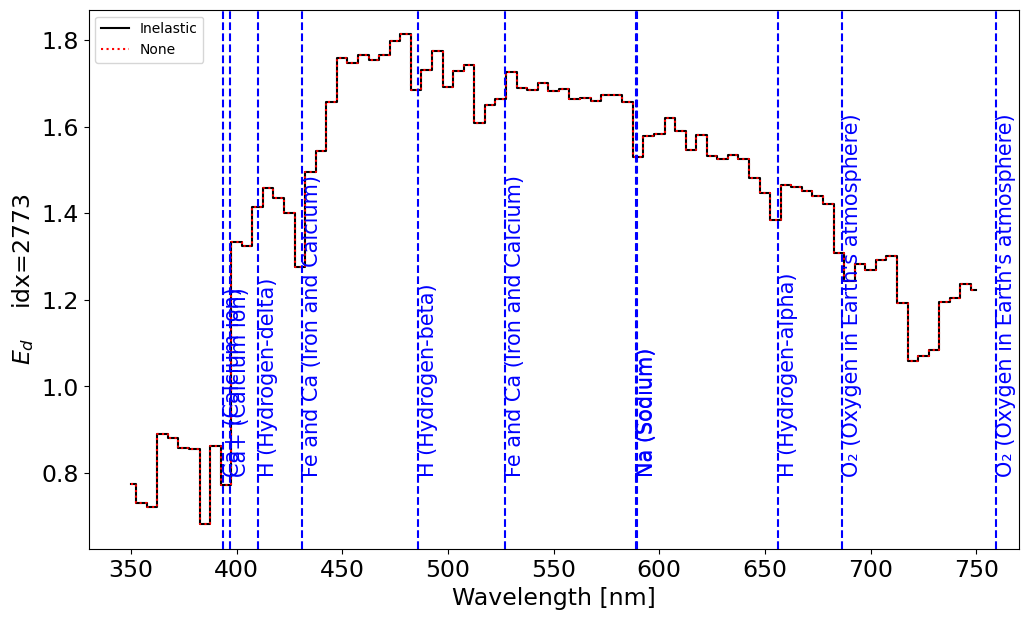

In [57]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()

# Ed
ax.plot(l23_wave, all_Ed[idx], 'k', drawstyle='steps-mid', label='Inelastic')
ax.plot(l23_wave, all_Edn[idx], 'r:', drawstyle='steps-mid', label='None')

# Add Fraunhoffer
for ss in range(len(fraun)):
    item = fraun.iloc[ss]
    ax.axvline(item.Wavelength_nm, ls='--', color='b')
    ax.text(item.Wavelength_nm, 0.8, item['Ion_Molecule'], rotation=90,
           fontsize=15., color='b')
#
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$E_d$'+f'    idx={idx}')
ax.legend()
#
oc_plotting.set_fontsize(ax, 17)
#
plt.show()

# $L_w$

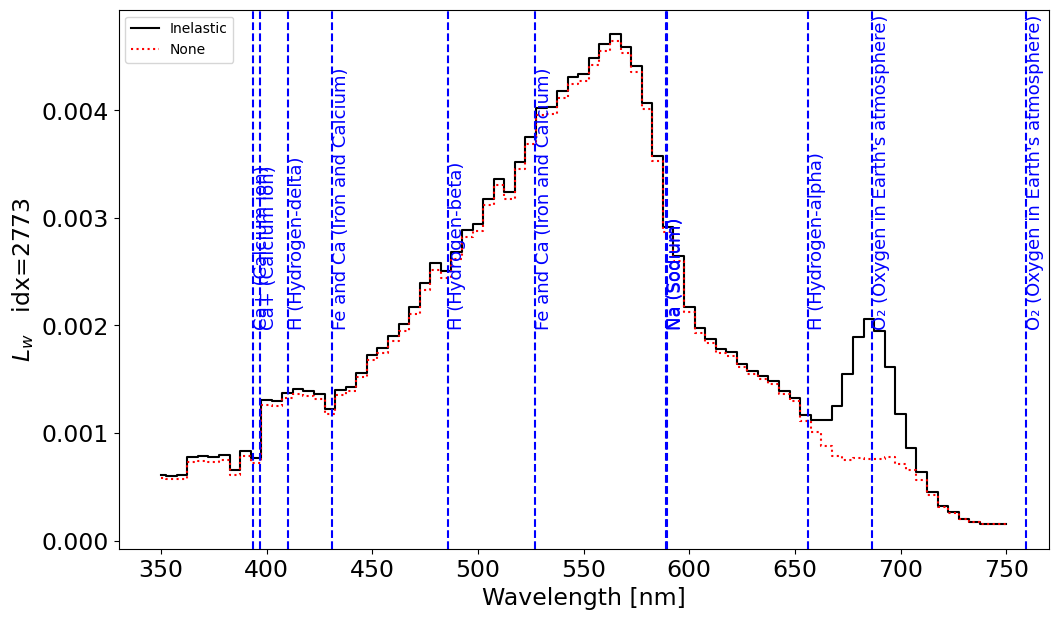

In [58]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()

# Ed
ax.plot(l23_wave, all_Lw[idx], 'k', drawstyle='steps-mid', label='Inelastic')
ax.plot(l23_wave, all_Lwn[idx], 'r:', drawstyle='steps-mid', label='None')

# Add Fraunhoffer
for ss in range(len(fraun)):
    item = fraun.iloc[ss]
    ax.axvline(item.Wavelength_nm, ls='--', color='b')
    ax.text(item.Wavelength_nm, 0.002, item['Ion_Molecule'], rotation=90,
           fontsize=13., color='b')
#
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$L_w$'+f'   idx={idx}')
ax.legend()
#
oc_plotting.set_fontsize(ax, 17)
#
plt.show()

# $R_{\rm rs}$

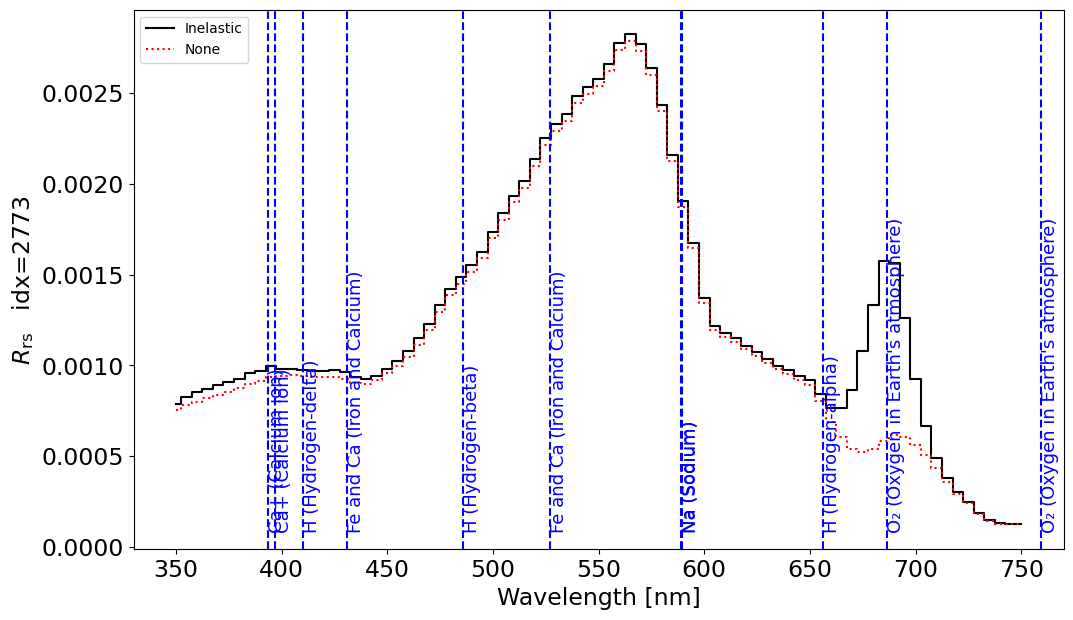

In [61]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()

# Ed
ax.plot(l23_wave, l23_Rrs[idx], 'k', drawstyle='steps-mid', label='Inelastic')
ax.plot(l23_wave, l23_Rrsn[idx], 'r:', drawstyle='steps-mid', label='None')

# Add Fraunhoffer
for ss in range(len(fraun)):
    item = fraun.iloc[ss]
    ax.axvline(item.Wavelength_nm, ls='--', color='b')
    ax.text(item.Wavelength_nm, 0.0001, item['Ion_Molecule'], rotation=90,
           fontsize=13., color='b')
#
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{\rm rs}$'+f'   idx={idx}')
ax.legend()
#
oc_plotting.set_fontsize(ax, 17)
#
plt.show()

## More

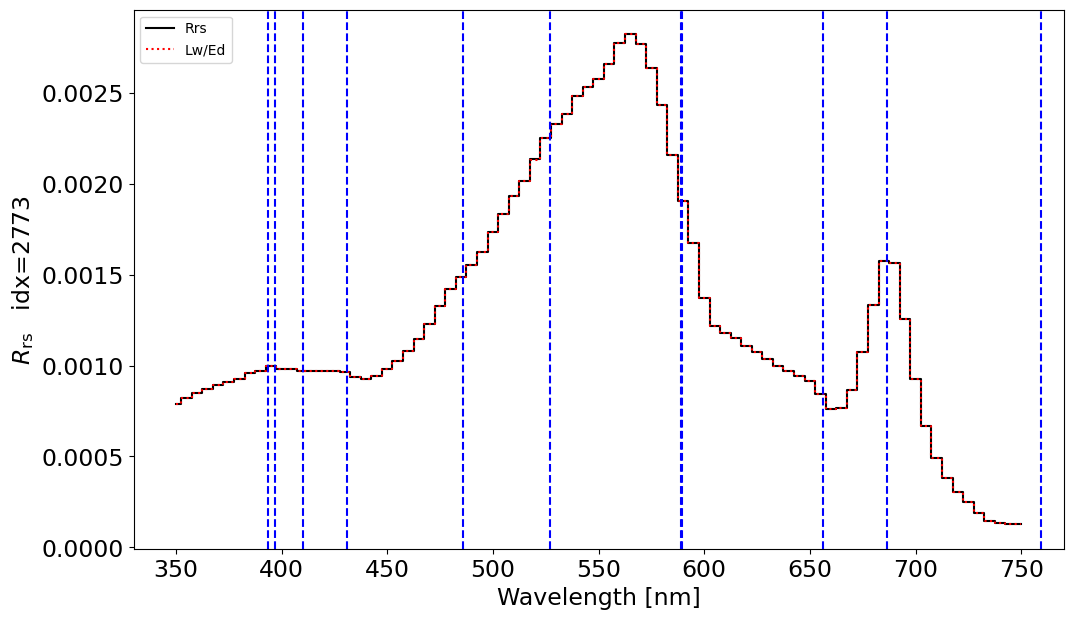

In [60]:
Rrs2 = all_Lw / all_Ed

fig = plt.figure(figsize=(12,7))
ax = plt.gca()

# Ed
ax.plot(l23_wave, l23_Rrs[idx], 'k', drawstyle='steps-mid', label='Rrs')
ax.plot(l23_wave, Rrs2[idx], 'r:', drawstyle='steps-mid', label='Lw/Ed')

# Add Fraunhoffer
for ss in range(len(fraun)):
    item = fraun.iloc[ss]
    ax.axvline(item.Wavelength_nm, ls='--', color='b')
    #ax.text(item.Wavelength_nm, 0.002, item['Ion_Molecule'], rotation=90,
    #       fontsize=13., color='b')
#
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'$R_{\rm rs}$'+f'   idx={idx}')
ax.legend()
#
oc_plotting.set_fontsize(ax, 17)
#
plt.show()